# EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from imblearn.combine import SMOTEENN
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import ADASYN
from imblearn.over_sampling import SMOTE

from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings('ignore')

# Cài đặt kích thước mặc định cho các biểu đồ
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Đọc dữ liệu
# Tập dữ liệu có 3 nhãn class: 0 (Không bị tiểu đường), 1 (Tiền tiểu đường), 2 (Tiểu đường)
df = pd.read_csv('archive/diabetes_012_health_indicators_BRFSS2015.csv')

print(f"Kích thước tập dữ liệu: {df.shape}")
df.head()

Kích thước tập dữ liệu: (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
# Kiểm tra thông tin chung và giá trị thiếu
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [4]:
# Kiểm tra dữ liệu trùng lặp
n_duplicates = df.duplicated().sum()
print(f"\nSố lượng dòng bị trùng lặp: {n_duplicates} ({n_duplicates/len(df)*100:.2f}%)")


Số lượng dòng bị trùng lặp: 23899 (9.42%)


Số lượng mẫu theo lượng nhãn:
Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

Tỉ lệ % theo nhãn:
Diabetes_012
0.0    84.241170
2.0    13.933302
1.0     1.825528
Name: proportion, dtype: float64


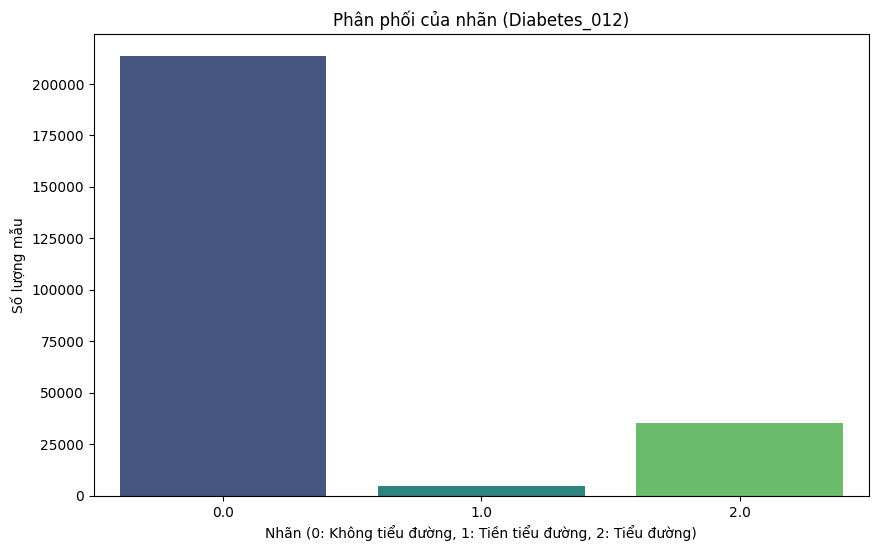

In [5]:
# Kiểm tra sự mất cân bằng dữ liệu của class 'Diabetes_012'
class_counts = df['Diabetes_012'].value_counts()
class_percentages = df['Diabetes_012'].value_counts(normalize=True) * 100

print("Số lượng mẫu theo lượng nhãn:")
print(class_counts)
print("\nTỉ lệ % theo nhãn:")
print(class_percentages)

# Trực quan hóa phân phối nhãn
sns.countplot(data=df, x='Diabetes_012', palette='viridis')
plt.title('Phân phối của nhãn (Diabetes_012)')
plt.xlabel('Nhãn (0: Không tiểu đường, 1: Tiền tiểu đường, 2: Tiểu đường)')
plt.ylabel('Số lượng mẫu')
plt.show()

Bộ dữ liệu gồm 229781 hàng (mẫu) và 22 cột, trong đó có 3 biến định lượng là BMI, MentHlth, PhysHlth, 4 biến định tính thứ bậc Age, Education, Income, GenHlth và các biến còn lại là định tính. Trong đó, các biến có dạng như sau:
- Diabetes_012: tình trạng bệnh tiểu đường (0: không tiểu đường, 1: tiền tiểu đường, 2: tiểu đường).
- HighBP: tình trạng cao huyết áp (0/1).
- HighChol: tình trạng cao cholesterol (0/1).
- CholCheck: kiểm tra cholesterol trong 5 năm (0/1).
- BMI: Body Mass Index.
- Smoke: người đã hút ít nhất 100 điếu thuốc trong suốt cuộc đời mình (0/1), [lưu ý: 5 gói = 100 điếu thuốc].
- Stroker: đã từng đột quỵ (0/1).
- HeartDiseaseorAttack: bệnh tim mạch vành (CHD) hoặc nhồi máu cơ tim (MI),(0/1).
- PhysActivity: hoạt động thể chất trong vòng 30 ngày, không tính hoạt động liên quan tới công việc, (0/1).
- Fruits: có ăn trái cây ít nhất 1 lần mỗi ngày (0/1).
- Veggies: có ăn rau/củ ít nhất 1 lần mỗi ngày (0/1).
- HvyAlcoholConsump: uống rượu/bia ở mức "nặng" (heavy drinking) (0/1).
- AnyHealthcare: có bảo hiểm y tế hoặc có khả năng tiếp cận dịch vụ chăm sóc sức khỏe (0/1).
- NoDocbcCost: trong 12 tháng qua có từng không đi khám bác sĩ vì chi phí quá cao (0/1).
- GenHlth: tự đánh giá sức khỏe tổng quát (1: Excellent → 5: Poor).
- MentHlth: số ngày sức khỏe tinh thần không tốt trong 30 ngày gần nhất (0–30).
- PhysHlth: số ngày sức khỏe thể chất không tốt trong 30 ngày gần nhất (0–30).
- DiffWalk: gặp khó khăn khi đi bộ hoặc leo cầu thang (0/1).
- Sex: giới tính (0: nữ, 1: nam).
- Age: tuổi (13 nhóm).
- Education: cấp giáo dục đã hoàn thành (6 cấp giáo dục).
- Income: mức thu nhập (8 mức thu nhập).

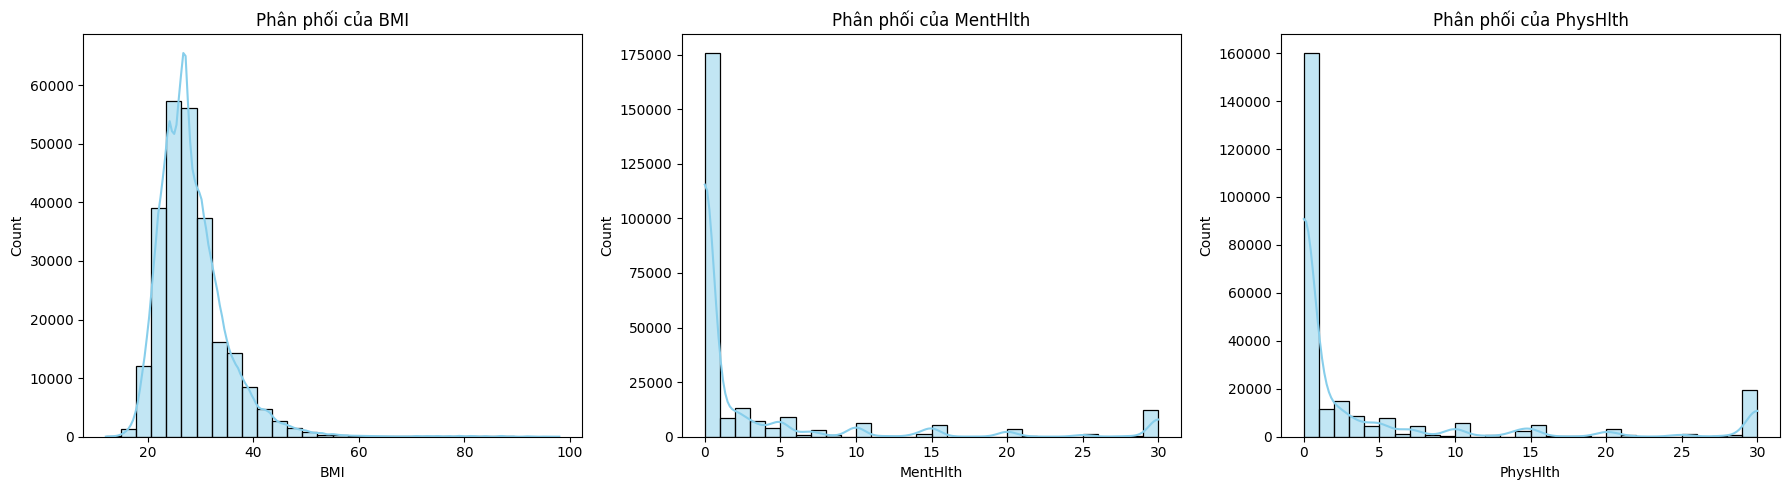

In [6]:
# Trực quan hóa 3 Biến định lượng: BMI, MentHlth, PhysHlth
quant_vars = ['BMI', 'MentHlth', 'PhysHlth']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, var in enumerate(quant_vars):
    sns.histplot(df[var], bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Phân phối của {var}')
plt.tight_layout()
plt.show()

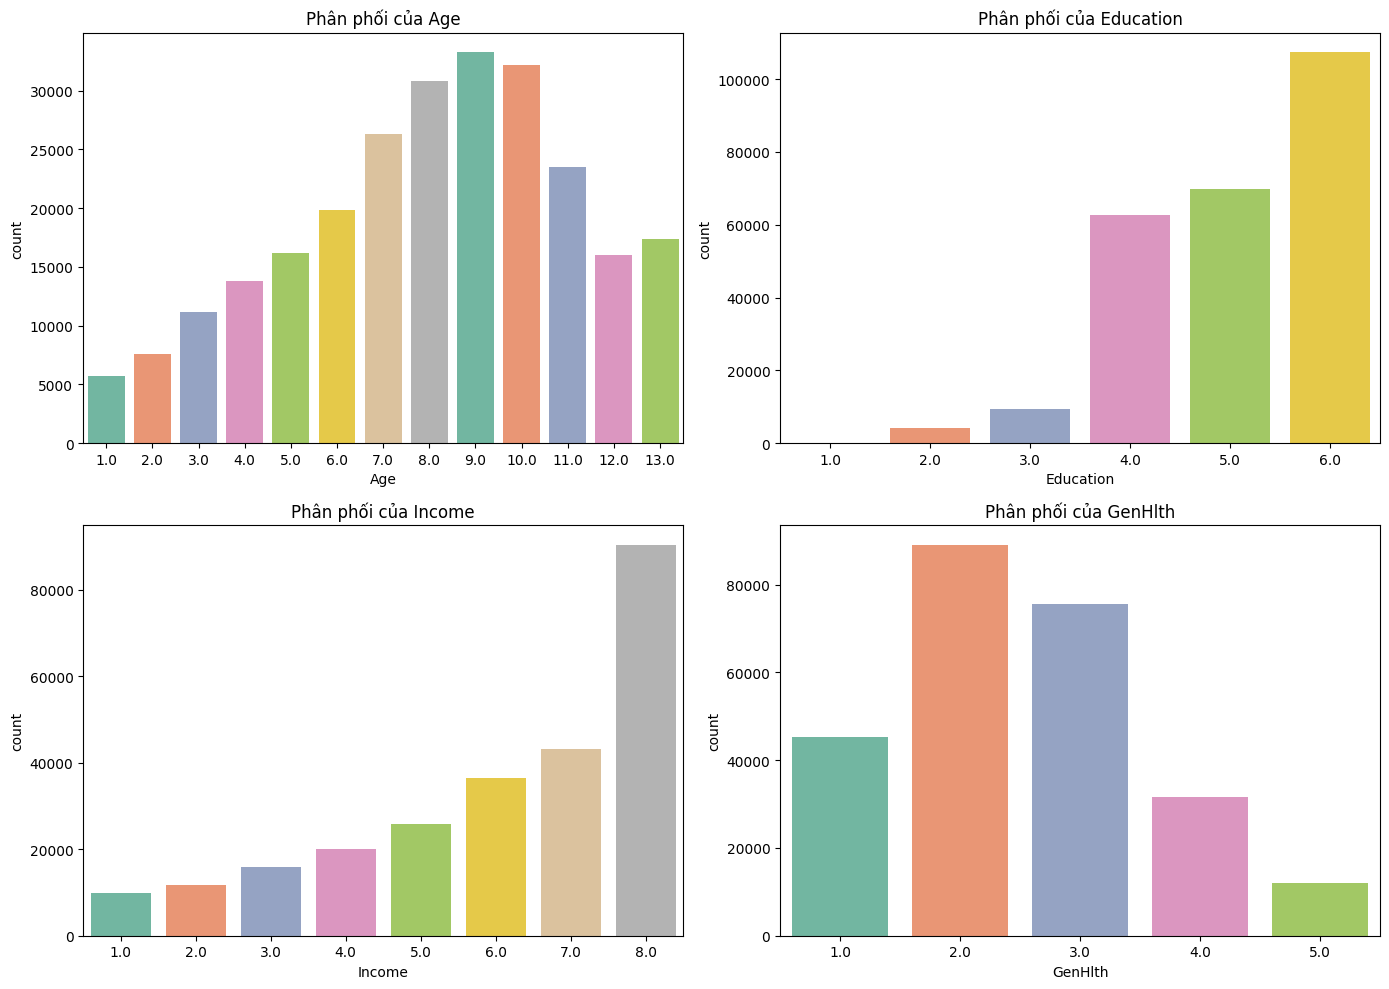

In [ ]:
# Trực quan hóa 4 Biến định tính thứ bậc: Age, Education, Income, GenHlth
ordinal_vars = ['Age', 'Education', 'Income', 'GenHlth']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, var in enumerate(ordinal_vars):
    sns.countplot(data=df, x=var, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Phân phối của {var}')
plt.tight_layout()
plt.show()

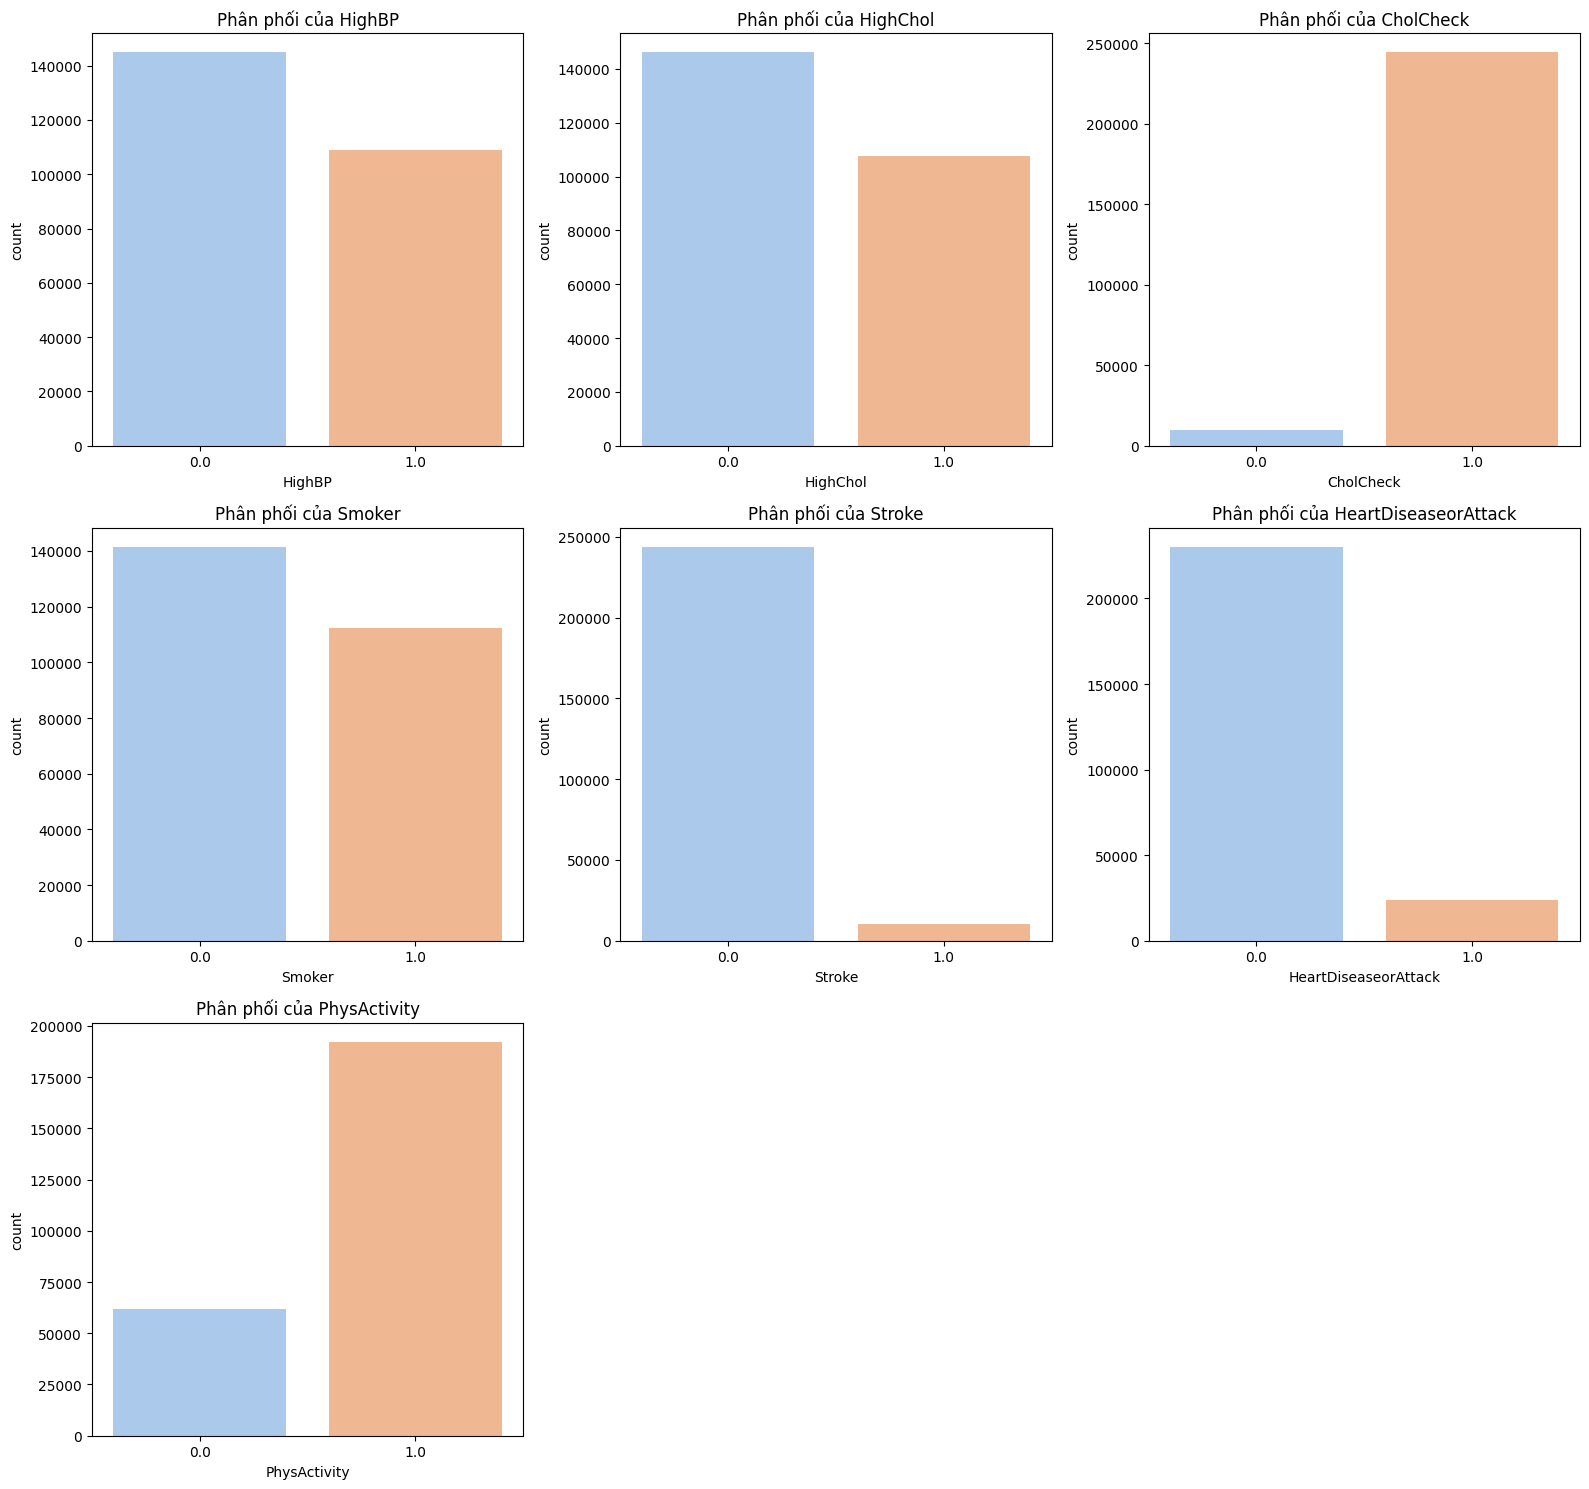

In [ ]:
# Trực quan hóa một số biến định tính còn lại
nom_vars = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity']

fig, axes = plt.subplots(3, 3, figsize=(16, 15))
axes = axes.flatten()
for i in range(7):
    sns.countplot(data=df, x=nom_vars[i], ax=axes[i], palette='pastel')
    axes[i].set_title(f'Phân phối của {nom_vars[i]}')

for i in range(7, 9):
    fig.delaxes(axes[i])
    
plt.tight_layout()
plt.show()

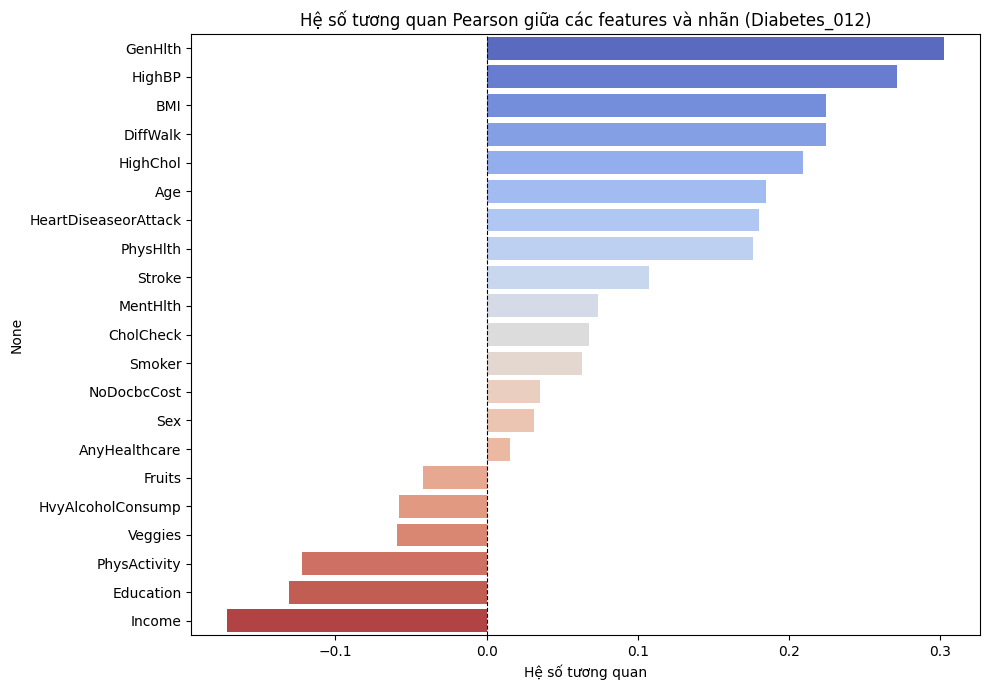

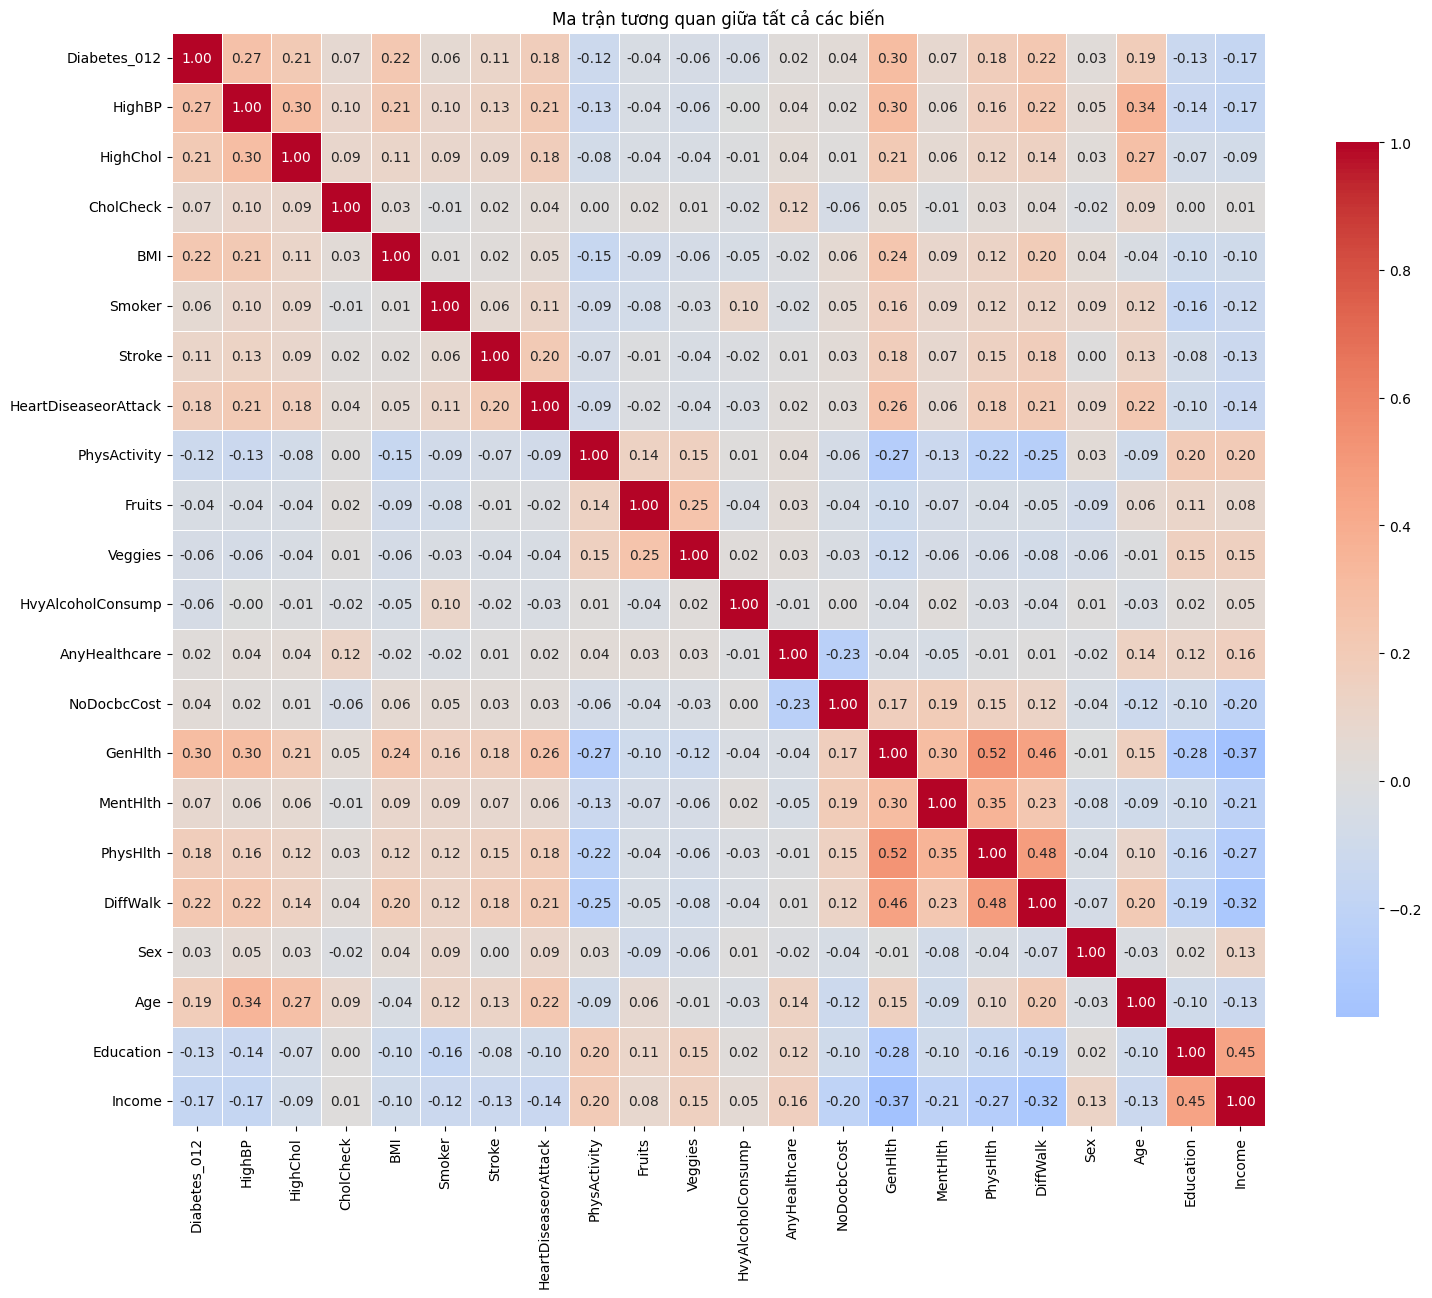

In [7]:
# Tương quan của từng feature với nhãn Diabetes_012
corr_with_target = df.corr()['Diabetes_012'].drop('Diabetes_012').sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')
plt.title('Hệ số tương quan Pearson giữa các features và nhãn (Diabetes_012)')
plt.xlabel('Hệ số tương quan')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

# Ma trận tương quan đầy đủ giữa tất cả các biến
plt.figure(figsize=(16, 13))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Ma trận tương quan giữa tất cả các biến')
plt.tight_layout()
plt.show()

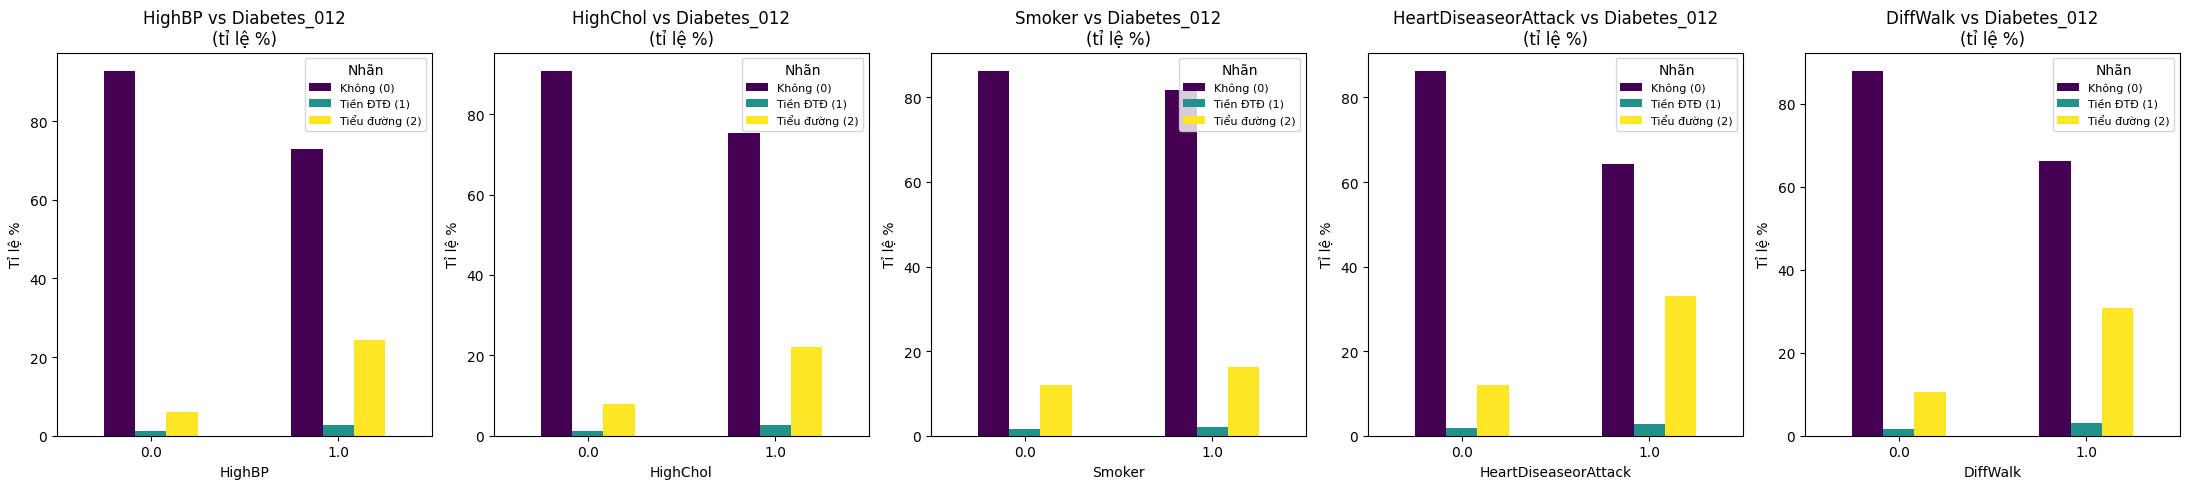

In [8]:
# Tỉ lệ phân bố Diabetes_012 theo từng biến nhị phân quan trọng
key_vars = ['HighBP', 'HighChol', 'Smoker', 'HeartDiseaseorAttack', 'DiffWalk']

fig, axes = plt.subplots(1, len(key_vars), figsize=(22, 5))
for i, var in enumerate(key_vars):
    ct = pd.crosstab(df[var], df['Diabetes_012'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], colormap='viridis', rot=0)
    axes[i].set_title(f'{var} vs Diabetes_012\n(tỉ lệ %)')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Tỉ lệ %')
    axes[i].legend(title='Nhãn', labels=['Không (0)', 'Tiền ĐTĐ (1)', 'Tiểu đường (2)'], fontsize=8)
plt.tight_layout()
plt.show()

# Chuẩn bị Dữ liệu (Train/Test)

In [9]:
# Loại bỏ dòng trùng lặp trước khi xử lý
df_no_dup = df.drop_duplicates().reset_index(drop=True)
print(f"Kích thước sau khi loại bỏ dòng trùng lặp: {df_no_dup.shape}")

# Chia tập dữ liệu thành Data (X) và Label (y)
X = df_no_dup.drop('Diabetes_012', axis=1)
y = df_no_dup['Diabetes_012']

print(f"Kích thước tập X ban đầu: {X.shape}")
print(f"Kích thước tập y ban đầu: {y.shape}")

# stratify=y đảm bảo tỉ lệ nhãn giữa train và test tương đồng
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nKích thước tập Train: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Kích thước tập Test:  X_test={X_test.shape},  y_test={y_test.shape}")

# Hàm dùng chung để trực quan hóa số lượng nhóm sau khi cân bằng
def plot_balanced_data(y_balanced, method_name):
    print(f"\n--- Số lượng mẫu sau {method_name} ---")
    print(pd.Series(y_balanced).value_counts())

    pd.Series(y_balanced).value_counts().sort_index().plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    plt.title(f'Phân phối nhãn sau khi dùng phương pháp {method_name}')
    plt.xlabel('Nhãn')
    plt.ylabel('Số lượng mẫu')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.75)
    plt.show()

Kích thước sau khi loại bỏ dòng trùng lặp: (229781, 22)
Kích thước tập X ban đầu: (229781, 21)
Kích thước tập y ban đầu: (229781,)

Kích thước tập Train: X_train=(183824, 21), y_train=(183824,)
Kích thước tập Test:  X_test=(45957, 21),  y_test=(45957,)


# Xử lý Outlier và Chuẩn hóa dữ liệu

In [10]:
# 1. XỬ LÝ OUTLIER — chỉ áp dụng trên tập Train để tránh Data Leakage
print(f"Kích thước X_train trước khi xóa Outlier: {X_train.shape}")

# Chỉ dùng Z-score cho 3 biến định lượng liên tục: BMI, MentHlth, PhysHlth
quant_vars = ['BMI', 'MentHlth', 'PhysHlth']

# Giữ lại các mẫu có Z-score < 3 (≈99.7% phân phối chuẩn)
z_scores = np.abs(stats.zscore(X_train[quant_vars]))
outliers_mask = (z_scores < 3).all(axis=1)

X_train_clean = X_train[outliers_mask].reset_index(drop=True)
y_train_clean = y_train[outliers_mask].reset_index(drop=True)

print(f"Kích thước X_train sau khi xử lý Outlier theo Z-score: {X_train_clean.shape}")
print(f"Số mẫu bị loại: {X_train.shape[0] - X_train_clean.shape[0]}")

Kích thước X_train trước khi xóa Outlier: (183824, 21)
Kích thước X_train sau khi xử lý Outlier theo Z-score: (171936, 21)
Số mẫu bị loại: 11888


In [11]:
# Phân nhóm biến:
# - Biến liên tục/thứ bậc nhiều mức → cần StandardScaler
continuous_vars = ['BMI', 'MentHlth', 'PhysHlth', 'GenHlth', 'Age', 'Education', 'Income']
# - Biến nhị phân (0/1) → giữ nguyên, không scale để tránh làm mất ý nghĩa
binary_vars = [col for col in X_train_clean.columns if col not in continuous_vars]

# 2. CHUẨN HÓA DỮ LIỆU
# fit_transform CHỈ trên X_train_clean, rồi chỉ transform X_test (tránh Data Leakage)
preprocessor = ColumnTransformer(transformers=[
    ('scale', StandardScaler(), continuous_vars)
], remainder='passthrough')

X_train_scaled = preprocessor.fit_transform(X_train_clean)
X_test_scaled  = preprocessor.transform(X_test)

# Khôi phục tên cột (ColumnTransformer đặt cột transform trước, passthrough sau)
feature_names = continuous_vars + binary_vars
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=feature_names)

print('Dữ liệu train sau khi chuẩn hóa (chỉ scale biến liên tục, giữ nguyên biến nhị phân):')
X_train_scaled_df.head()

Dữ liệu train sau khi chuẩn hóa (chỉ scale biến liên tục, giữ nguyên biến nhị phân):


,BMI,MentHlth,PhysHlth,GenHlth,Age,Education,Income,HighBP,HighChol,CholCheck,...,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex
0,-0.571264,2.941298,-0.485776,-0.524202,0.600900,0.001877,-0.475020,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
1,-1.269881,-0.439082,-0.365528,-0.524202,-1.327693,1.016568,0.501966,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
2,0.651316,-0.439082,-0.485776,0.448296,-1.649125,1.016568,0.990458,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
3,0.651316,-0.439082,-0.485776,0.448296,1.243764,0.001877,0.013473,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
4,1.000625,-0.439082,-0.485776,1.420794,0.922332,-1.012814,-0.475020,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


# Phân tích thành phần chính (PCA) và Giảm chiều

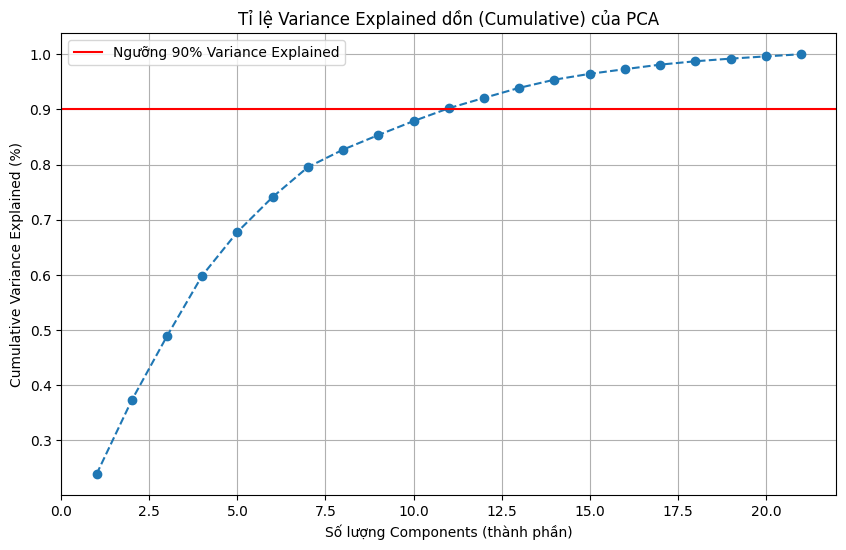

Số components tối thiểu giúp giữ lại >= 90% độ biến thiên thông tin là: 11
Kích thước X_train sau khi giảm chiều bằng PCA: (171936, 11)
Kích thước X_test  sau khi giảm chiều bằng PCA: (45957, 11)
Lưu ý: Feature Selection (tiếp theo) sẽ được ưu tiên dùng cho huấn luyện mô hình.


In [12]:
from sklearn.decomposition import PCA

# Chạy PCA trên X_train_scaled_df — fit chỉ trên Train để tránh Data Leakage
pca = PCA()
pca.fit(X_train_scaled_df)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-', label='Ngưỡng 90% Variance Explained')
plt.title('Tỉ lệ Variance Explained dồn (Cumulative) của PCA')
plt.xlabel('Số lượng Components (thành phần)')
plt.ylabel('Cumulative Variance Explained (%)')
plt.legend()
plt.grid(True)
plt.show()

n_comp_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Số components tối thiểu giúp giữ lại >= 90% độ biến thiên thông tin là: {n_comp_90}")

# Giảm chiều cả train và test bằng PCA đã fit trên train
pca_reduced = PCA(n_components=n_comp_90)
X_train_pca = pca_reduced.fit_transform(X_train_scaled_df)
X_test_pca  = pca_reduced.transform(X_test_scaled_df)
print(f"Kích thước X_train sau khi giảm chiều bằng PCA: {X_train_pca.shape}")
print(f"Kích thước X_test  sau khi giảm chiều bằng PCA: {X_test_pca.shape}")
print("Lưu ý: Feature Selection (tiếp theo) sẽ được ưu tiên dùng cho huấn luyện mô hình.")

# Lựa chọn đặc trưng (Feature Selection)

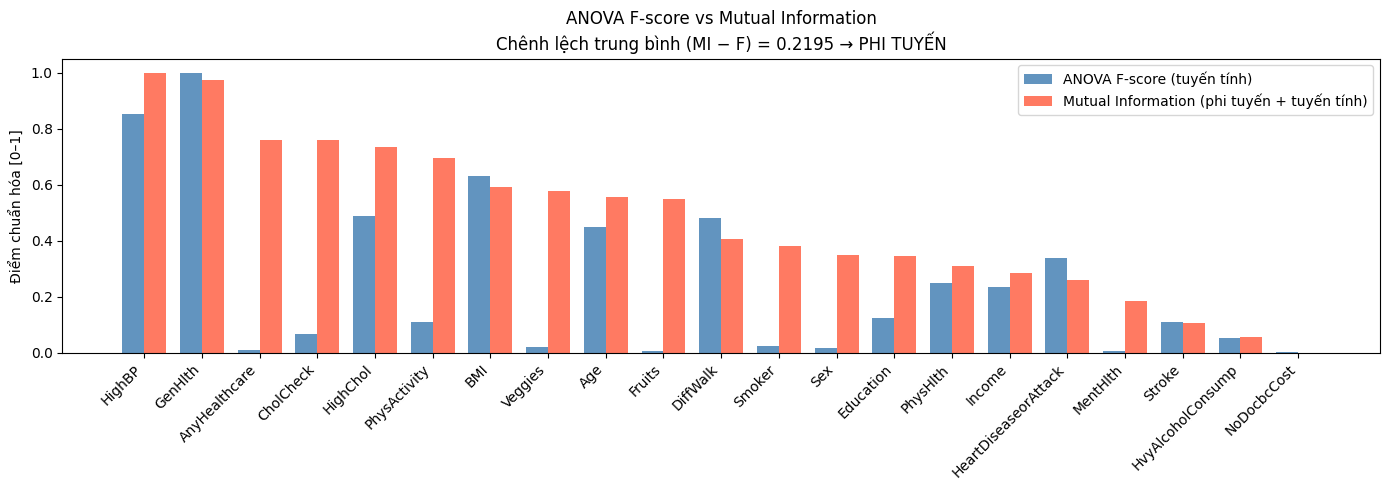

Chênh lệch MI − F = 0.2195 > 0.10  → Dữ liệu PHI TUYẾN
→ Dùng Mutual Information làm tiêu chí chọn feature.

Top 10 features quan trọng nhất theo Mutual Information:


,Feature,Score
7,HighBP,0.045016
3,GenHlth,0.043807
17,AnyHealthcare,0.034153
9,CholCheck,0.034115
8,HighChol,0.033114
13,PhysActivity,0.031335
0,BMI,0.026692
15,Veggies,0.026038
4,Age,0.025011
14,Fruits,0.024704



Các features được chọn (Mutual Information): ['BMI', 'GenHlth', 'Age', 'HighBP', 'HighChol', 'CholCheck', 'PhysActivity', 'Fruits', 'Veggies', 'AnyHealthcare']
Kích thước X_train sau Feature Selection: (171936, 10)
Kích thước X_test  sau Feature Selection: (45957, 10)


In [13]:
# ── BƯỚC 1: Phát hiện tính phi tuyến — So sánh MI vs ANOVA F-score ────────────
# ANOVA F-score chỉ đo mối quan hệ tuyến tính giữa feature và nhãn.
# Mutual Information đo mọi loại quan hệ (tuyến tính + phi tuyến).
# Nếu MI >> F-score → dữ liệu phi tuyến → cần dùng MI để chọn feature.

f_scores, _ = f_classif(X_train_scaled_df, y_train_clean)
mi_scores   = mutual_info_classif(X_train_scaled_df, y_train_clean, random_state=42)

# Chuẩn hóa về [0, 1] để so sánh cùng thang đo
f_norm  = f_scores  / f_scores.max()
mi_norm = mi_scores / mi_scores.max()
avg_gap = (mi_norm - f_norm).mean()

linearity_df = pd.DataFrame({
    'Feature':              list(X_train_scaled_df.columns),
    'ANOVA F-score':        f_norm,
    'Mutual Information':   mi_norm,
    'Chenh lech (MI-F)':    mi_norm - f_norm,
}).sort_values('Mutual Information', ascending=False).reset_index(drop=True)

x, width = np.arange(len(linearity_df)), 0.38
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, linearity_df['ANOVA F-score'],    width,
       label='ANOVA F-score (tuyến tính)', color='steelblue', alpha=0.85)
ax.bar(x + width/2, linearity_df['Mutual Information'], width,
       label='Mutual Information (phi tuyến + tuyến tính)', color='tomato', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(linearity_df['Feature'], rotation=45, ha='right')
ax.set_ylabel('Điểm chuẩn hóa [0–1]')
ax.set_title(f'ANOVA F-score vs Mutual Information\n'
             f'Chênh lệch trung bình (MI − F) = {avg_gap:.4f} '
             f'→ {"PHI TUYẾN" if avg_gap > 0.10 else "TUYẾN TÍNH"}')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ── BƯỚC 2: Chọn scoring function phù hợp với bản chất dữ liệu ────────────────
if avg_gap > 0.10:
    # Phi tuyến rõ rệt → dùng MI để chọn feature, tránh bỏ sót quan hệ phi tuyến
    score_func  = lambda X, y: mutual_info_classif(X, y, random_state=42)
    method_name = 'Mutual Information'
    print(f"Chênh lệch MI − F = {avg_gap:.4f} > 0.10  → Dữ liệu PHI TUYẾN")
    print("→ Dùng Mutual Information làm tiêu chí chọn feature.\n")
else:
    # Tuyến tính → ANOVA F-score vẫn phù hợp
    score_func  = f_classif
    method_name = 'ANOVA F-score'
    print(f"Chênh lệch MI − F = {avg_gap:.4f} ≤ 0.10 → Dữ liệu TUYẾN TÍNH")
    print("→ Dùng ANOVA F-score làm tiêu chí chọn feature.\n")

# ── BƯỚC 3: Chạy SelectKBest với scoring function đã xác định ──────────────────
# Fit CHỈ trên tập Train để tránh Data Leakage
kbest = SelectKBest(score_func=score_func, k=10)
kbest.fit(X_train_scaled_df, y_train_clean)

kbest_scores = pd.DataFrame({
    'Feature': X_train_scaled_df.columns,
    'Score':   kbest.scores_
}).sort_values(by='Score', ascending=False)

print(f"Top 10 features quan trọng nhất theo {method_name}:")
display(kbest_scores.head(10))

# Áp dụng selection lên cả train và test
X_train_top10 = kbest.transform(X_train_scaled_df)
X_test_top10  = kbest.transform(X_test_scaled_df)

selected_features = X_train_scaled_df.columns[kbest.get_support()].tolist()
print(f"\nCác features được chọn ({method_name}): {selected_features}")
print(f"Kích thước X_train sau Feature Selection: {X_train_top10.shape}")
print(f"Kích thước X_test  sau Feature Selection: {X_test_top10.shape}")

> **Lựa chọn Feature Selection thay vì PCA:** PCA biến đổi features thành các thành phần không có ý nghĩa giải thích được. Trong bài toán y tế, tính giải thích (interpretability) rất quan trọng, nên Feature Selection (SelectKBest) được chọn làm hướng giảm chiều chính.

> **Scoring function thích ứng theo bản chất dữ liệu:** Thay vì cố định dùng ANOVA F-score (chỉ đo quan hệ tuyến tính), cell trên tự động so sánh MI vs F-score để phát hiện tính phi tuyến. Nếu `avg_gap > 0.10` → dùng **Mutual Information** (nắm bắt quan hệ phi tuyến); ngược lại → dùng **ANOVA F-score**. Cách này đảm bảo `X_train_top10` và `X_test_top10` chứa đúng các features quan trọng nhất phù hợp với bản chất thực của dữ liệu — và sẽ được dùng cho toàn bộ các bước tiếp theo (resampling, huấn luyện mô hình, đánh giá).

# Xử lý mất cân bằng

## SMOTE


--- Số lượng mẫu sau SMOTE ---
Diabetes_012
0.0    143391
2.0    143391
1.0    143391
Name: count, dtype: int64


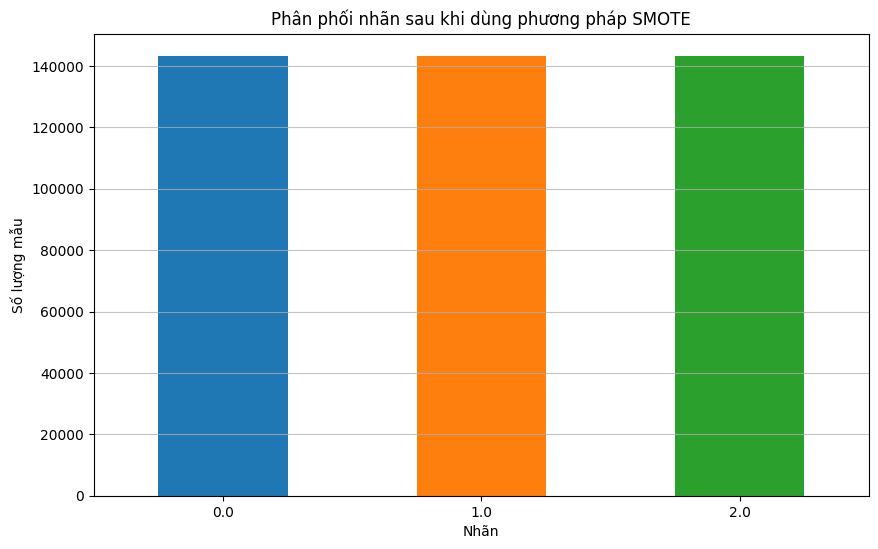

In [14]:
# Tăng mẫu bằng cách nội suy
# X_train_top10: features chọn bằng MI/ANOVA tùy bản chất dữ liệu (xem cell trên)
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_top10, y_train_clean)

plot_balanced_data(y_smote, 'SMOTE')

## ADASYN


--- Số lượng mẫu sau ADASYN ---
Diabetes_012
1.0    143652
0.0    143391
2.0    142575
Name: count, dtype: int64


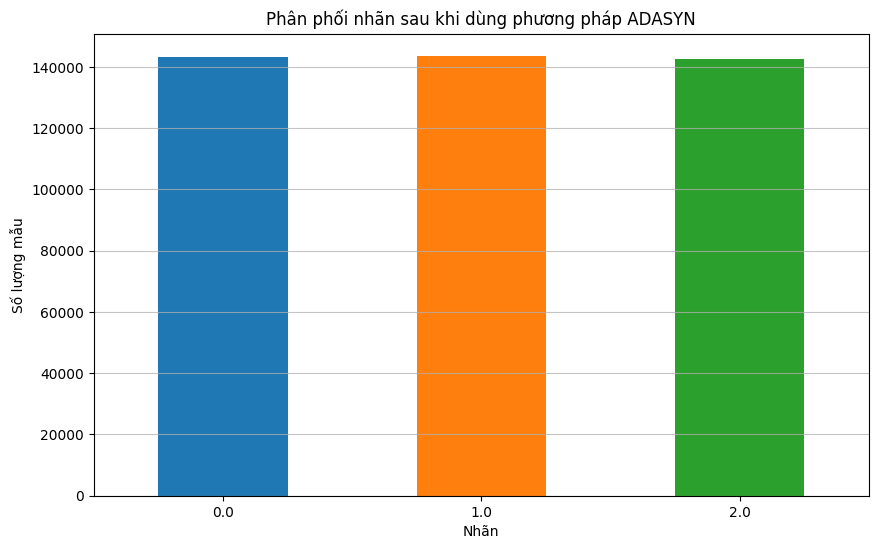

In [15]:
# Adaptive Synthetic Sampling
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_top10, y_train_clean)

plot_balanced_data(y_adasyn, 'ADASYN')

## ROS


--- Số lượng mẫu sau ROS ---
Diabetes_012
0.0    143391
2.0    143391
1.0    143391
Name: count, dtype: int64


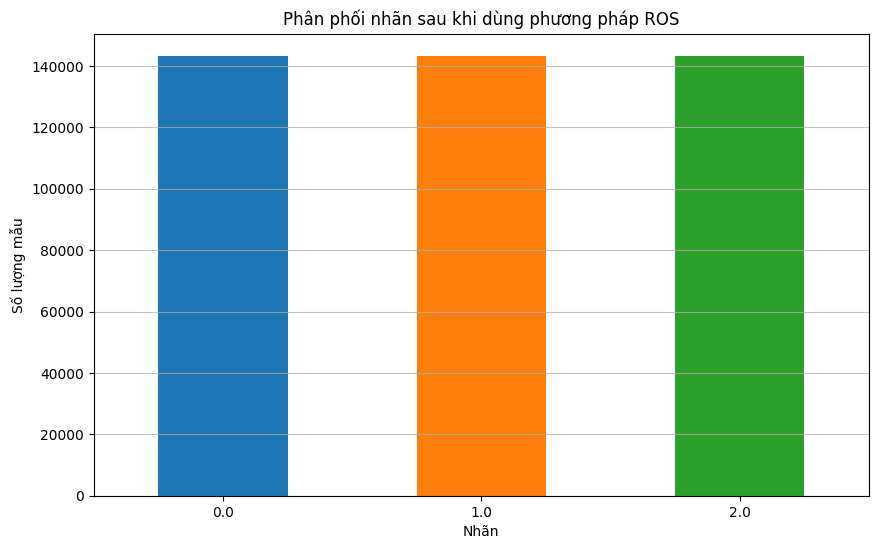

In [16]:
# Random Over Sampling
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train_top10, y_train_clean)

plot_balanced_data(y_ros, 'ROS')

## RUS


--- Số lượng mẫu sau RUS ---
Diabetes_012
0.0    3340
1.0    3340
2.0    3340
Name: count, dtype: int64


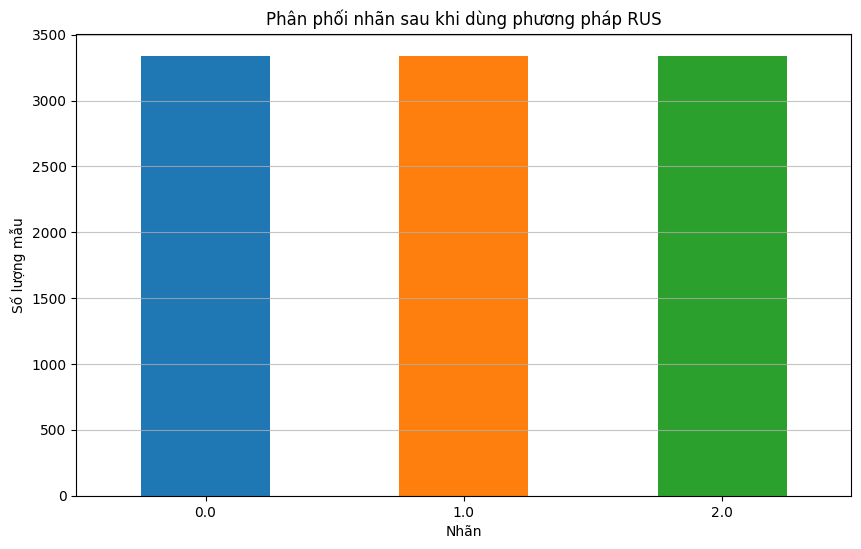

In [17]:
# Random Under Sampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train_top10, y_train_clean)

plot_balanced_data(y_rus, 'RUS')

## Tomek Links


--- Số lượng mẫu sau Tomek Links (nguyên bản) ---
Diabetes_012
0.0    142484
2.0     24382
1.0      3340
Name: count, dtype: int64


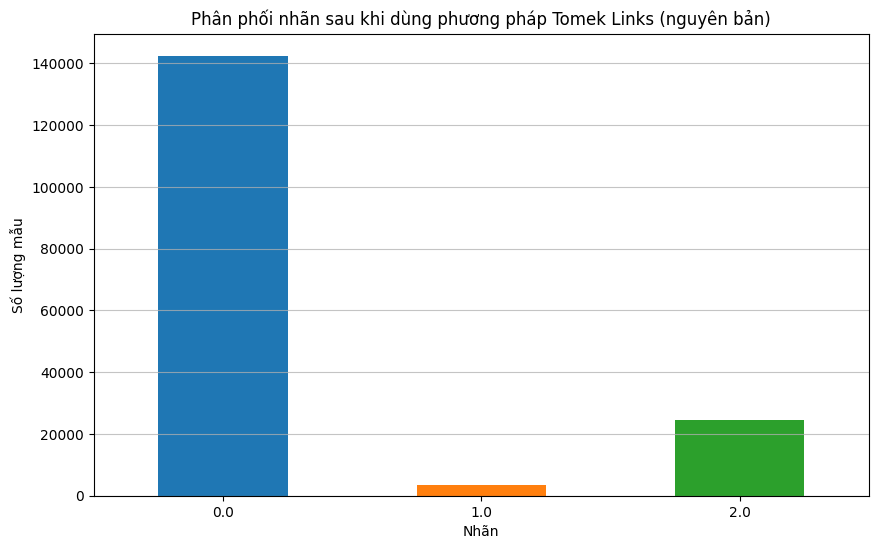

In [18]:
# Tomek Links
tomek = TomekLinks(n_jobs=-1)
X_tomek, y_tomek = tomek.fit_resample(X_train_top10, y_train_clean)

plot_balanced_data(y_tomek, 'Tomek Links (nguyên bản)')

## SMOTE+ENN


--- Số lượng mẫu sau SMOTE+ENN (nguyên bản) ---
Diabetes_012
1.0    99344
0.0    96538
2.0    44299
Name: count, dtype: int64


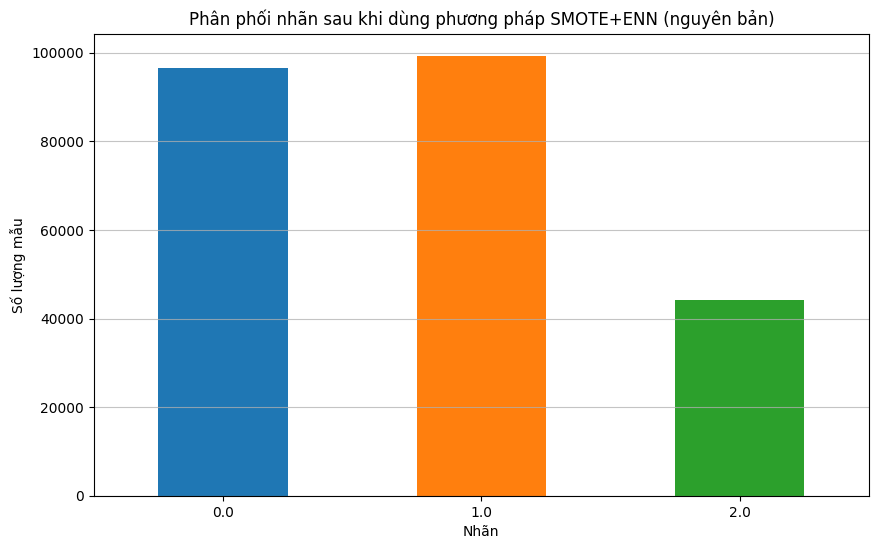

In [19]:
# SMOTE+ENN
smote_enn = SMOTEENN(random_state=42, n_jobs=-1)
X_smote_enn, y_smote_enn = smote_enn.fit_resample(X_train_top10, y_train_clean)

plot_balanced_data(y_smote_enn, 'SMOTE+ENN (nguyên bản)')

# Tiêu chí đánh giá mô hình

Dữ liệu mất cân bằng nghiêm trọng (class 0 ≈84%, class 1 ≈14%, class 2 ≈2%), nên **Accuracy không phải tiêu chí chính** (mô hình luôn đoán class 0 cũng đạt ~84% mà không học gì).

| Tiêu chí | Mô tả | Mức ưu tiên |
|---|---|---|
| **Macro F1** | F1 trung bình đều nhau cho 3 class — không bị bias bởi class đa số | **Chỉ số chính** |
| **Recall (class 2)** | Tỉ lệ phát hiện đúng bệnh nhân tiểu đường thực sự — tránh bỏ sót | **Ưu tiên cao trong y tế** |
| **Confusion Matrix** | Phân tích chi tiết loại lỗi nhầm từng class | Phụ trợ |
| **Classification Report** | Precision, Recall, F1 đầy đủ từng class | Phụ trợ |

**Dữ liệu dùng khi đánh giá:**
- Huấn luyện: `X_train_top10` (sau resampling) + nhãn tương ứng
- Đánh giá: `X_test_top10` + `y_test` *(chưa qua resampling — phản ánh phân phối thực tế)*

# Giai đoạn 1 — Chọn Phương pháp Tái cân bằng Tốt nhất

Trước khi huấn luyện các mô hình học máy, cần xác định phương pháp xử lý mất cân bằng nào mang lại hiệu quả tốt nhất. Sáu phương pháp trên (SMOTE, ADASYN, ROS, RUS, Tomek Links, SMOTE+ENN) tạo ra các tập train với kích thước và phân phối khác nhau — **không thể khẳng định resampler nào vượt trội mà không thực nghiệm**.

**Phương pháp so sánh:**
- **Proxy model**: Random Forest (`n_estimators=100`) — đủ mạnh để phản ánh chất lượng dữ liệu sau resampling, không yêu cầu tuning phức tạp, hỗ trợ xử lý song song (`n_jobs=-1`).
- **Quy trình**: Train trên mỗi tập đã resample → Predict trên `X_test_top10` gốc (không resample, phản ánh phân phối thực tế).
- **Tiêu chí chọn**: **Macro F1** (chỉ số chính, không bị bias bởi class đa số) + **Recall class 2** (ưu tiên phát hiện bệnh nhân tiểu đường).
- **Đầu ra**: Resampler tốt nhất → `X_best, y_best` → dùng cho Giai đoạn 2 (huấn luyện tất cả mô hình).

=== Giai doan 1: So sanh Resampling Methods (Proxy = Random Forest) ===

[SMOTE       ]  Macro F1 = 0.4175  |  Recall class 2 = 0.4532  (32.6s)
[ADASYN      ]  Macro F1 = 0.4159  |  Recall class 2 = 0.4680  (29.3s)
[ROS         ]  Macro F1 = 0.3864  |  Recall class 2 = 0.4807  (26.3s)
[RUS         ]  Macro F1 = 0.3523  |  Recall class 2 = 0.4630  (1.1s)
[Tomek Links ]  Macro F1 = 0.3972  |  Recall class 2 = 0.2147  (7.5s)
[SMOTE+ENN   ]  Macro F1 = 0.4178  |  Recall class 2 = 0.4217  (13.0s)

-- Bang ket qua (sap xep giam dan theo Macro F1) --


,Resampling,Macro F1,Recall class 2,So mau train
1,SMOTE+ENN,0.4178,0.4217,240181
2,SMOTE,0.4175,0.4532,430173
3,ADASYN,0.4159,0.4680,429618
4,Tomek Links,0.3972,0.2147,170206
5,ROS,0.3864,0.4807,430173
6,RUS,0.3523,0.4630,10020


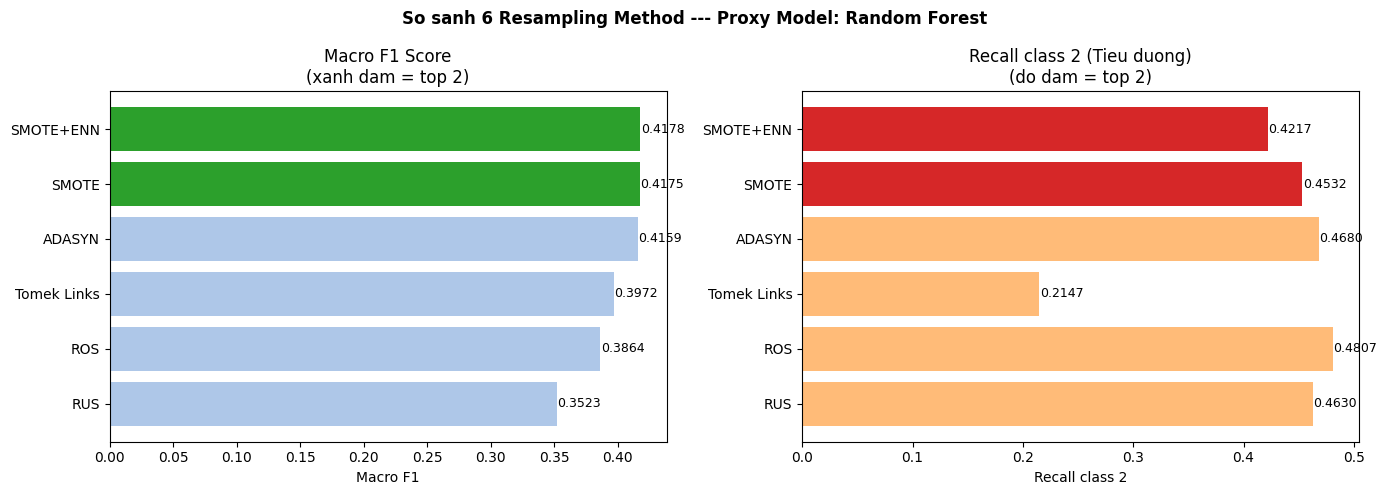

Top 2 resampling tot nhat (theo Macro F1): ['SMOTE+ENN', 'SMOTE']
  SMOTE+ENN: Macro F1=0.4178, Recall class 2=0.4217
  SMOTE: Macro F1=0.4175, Recall class 2=0.4532

>> Su dung [SMOTE+ENN] cho Giai doan 2 (huan luyen tat ca mo hinh).
   X_best=(240181, 10), y_best: 240181 mau


In [20]:
from sklearn.metrics import f1_score, recall_score
import time

# ── PROXY MODEL: Random Forest ─────────────────────────────────────────────────
# Train proxy trên tập đã resample, evaluate trên test gốc — tránh data leakage
def evaluate_proxy(X_train_res, y_train_res, name):
    t0    = time.time()
    proxy = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    proxy.fit(X_train_res, y_train_res)
    y_pred    = proxy.predict(X_test_top10)
    macro_f1  = f1_score(y_test, y_pred, average='macro')
    recall_c2 = recall_score(y_test, y_pred, average=None)[2]
    elapsed   = time.time() - t0
    print(f"[{name:<12}]  Macro F1 = {macro_f1:.4f}  |  Recall class 2 = {recall_c2:.4f}  ({elapsed:.1f}s)")
    return {
        'Resampling':     name,
        'Macro F1':       round(macro_f1, 4),
        'Recall class 2': round(recall_c2, 4),
        'So mau train':   len(y_train_res),
    }

# ── CHẠY 6 RESAMPLER ───────────────────────────────────────────────────────────
resamplers = [
    (X_smote,     y_smote,     'SMOTE'),
    (X_adasyn,    y_adasyn,    'ADASYN'),
    (X_ros,       y_ros,       'ROS'),
    (X_rus,       y_rus,       'RUS'),
    (X_tomek,     y_tomek,     'Tomek Links'),
    (X_smote_enn, y_smote_enn, 'SMOTE+ENN'),
]

print("=== Giai doan 1: So sanh Resampling Methods (Proxy = Random Forest) ===\n")
results    = [evaluate_proxy(X_r, y_r, name) for X_r, y_r, name in resamplers]
results_df = (pd.DataFrame(results)
                .sort_values('Macro F1', ascending=False)
                .reset_index(drop=True))
results_df.index += 1  # rank bat dau tu 1

print("\n-- Bang ket qua (sap xep giam dan theo Macro F1) --")
display(results_df)

# ── BIỂU ĐỒ SO SÁNH ────────────────────────────────────────────────────────────
# Đảo thứ tự để rank 1 hiển thị ở trên cùng của biểu đồ ngang
order = results_df['Resampling'].tolist()[::-1]
f1_v  = results_df['Macro F1'].tolist()[::-1]
r2_v  = results_df['Recall class 2'].tolist()[::-1]
# 4 hàng dưới (rank 6→3) màu nhạt, 2 hàng trên (rank 2→1) màu đậm
c_f1  = ['#aec7e8'] * 4 + ['#2ca02c'] * 2
c_r2  = ['#ffbb78'] * 4 + ['#d62728'] * 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(order, f1_v, color=c_f1)
axes[0].set_title('Macro F1 Score\n(xanh dam = top 2)')
axes[0].set_xlabel('Macro F1')
for i, v in enumerate(f1_v):
    axes[0].text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=9)

axes[1].barh(order, r2_v, color=c_r2)
axes[1].set_title('Recall class 2 (Tieu duong)\n(do dam = top 2)')
axes[1].set_xlabel('Recall class 2')
for i, v in enumerate(r2_v):
    axes[1].text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('So sanh 6 Resampling Method --- Proxy Model: Random Forest',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── KẾT LUẬN: CHỌN RESAMPLER TỐT NHẤT → X_best ───────────────────────────────
best_name  = results_df.iloc[0]['Resampling']
top2_names = results_df.head(2)['Resampling'].tolist()

print(f"Top 2 resampling tot nhat (theo Macro F1): {top2_names}")
for _, row in results_df.head(2).iterrows():
    print(f"  {row['Resampling']}: Macro F1={row['Macro F1']:.4f}, Recall class 2={row['Recall class 2']:.4f}")

best_data_map = {
    'SMOTE':       (X_smote,     y_smote),
    'ADASYN':      (X_adasyn,    y_adasyn),
    'ROS':         (X_ros,       y_ros),
    'RUS':         (X_rus,       y_rus),
    'Tomek Links': (X_tomek,     y_tomek),
    'SMOTE+ENN':   (X_smote_enn, y_smote_enn),
}
X_best, y_best = best_data_map[best_name]
print(f"\n>> Su dung [{best_name}] cho Giai doan 2 (huan luyen tat ca mo hinh).")
print(f"   X_best={X_best.shape}, y_best: {len(y_best)} mau")

# Giai đoạn 2 — Huấn luyện và So sánh Mô hình

Dựa trên kết quả Giai đoạn 1, **SMOTE** và **SMOTE+ENN** là hai phương pháp tái cân bằng tốt nhất. Giai đoạn 2 huấn luyện 5 mô hình đại diện cho các nhóm thuật toán khác nhau, mỗi mô hình được thử nghiệm trên **3 điều kiện dữ liệu**:

| Điều kiện | Dữ liệu train | Mục đích |
|---|---|---|
| **Không resample** | `X_train_top10` (gốc, mất cân bằng 84/14/2%) | Baseline — không can thiệp |
| **SMOTE** | `X_smote` (over-sampling tổng hợp) | Tái cân bằng bằng nội suy KNN |
| **SMOTE+ENN** | `X_smote_enn` (over+under kết hợp) | Tái cân bằng + làm sạch biên giới |

**5 mô hình được chọn:**

| Mô hình | Nhóm | Kỳ vọng với dữ liệu phi tuyến |
|---|---|---|
| Logistic Regression | Tuyến tính | Baseline — kết quả thấp nhất |
| RBF SVM | Kernel | Phi tuyến qua kernel trick, nhưng chậm |
| Random Forest | Ensemble (Bagging) | Tốt — phi tuyến, kháng nhiễu |
| XGBoost | Ensemble (Boosting) | Rất tốt — mạnh với dữ liệu dạng bảng |
| MLP | Neural Network | Tốt — học quan hệ phi tuyến phức tạp |

> **Bất biến**: Tập test `X_test_top10 + y_test` **không** qua resampling trong mọi trường hợp — đánh giá trên phân phối thực tế.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, recall_score, roc_auc_score
import time

# 3 điều kiện thí nghiệm — nhãn chuyển sang int để tương thích với XGBoost
datasets_exp = {
    'Khong resample': (np.array(X_train_top10), np.array(y_train_clean).astype(int)),
    'SMOTE':          (np.array(X_smote),        np.array(y_smote).astype(int)),
    'SMOTE+ENN':      (np.array(X_smote_enn),    np.array(y_smote_enn).astype(int)),
}
X_test_arr = np.array(X_test_top10)
y_test_arr = np.array(y_test).astype(int)


def run_model(model, model_name, subset_size=None):
    """
    Train model tren 3 dieu kien, evaluate tren tap test goc.
    subset_size: neu khac None, chi lay subset_size mau ngau nhien de train.
    """
    print(f"\n{'='*62}")
    print(f"  {model_name}")
    print(f"{'='*62}")

    rows = []
    for ds_name, (X_tr, y_tr) in datasets_exp.items():
        if subset_size and len(X_tr) > subset_size:
            rng  = np.random.RandomState(42)
            idx  = rng.choice(len(X_tr), subset_size, replace=False)
            X_tr, y_tr = X_tr[idx], y_tr[idx]
            note = f' (subset {subset_size // 1000}K)'
        else:
            note = ''

        t0      = time.time()
        model.fit(X_tr, y_tr)
        y_pred  = model.predict(X_test_arr)
        elapsed = time.time() - t0

        macro_f1  = f1_score(y_test_arr, y_pred, average='macro')
        recall_c2 = recall_score(y_test_arr, y_pred, average=None)[2]
        roc_auc   = roc_auc_score(y_test_arr, model.predict_proba(X_test_arr), multi_class='ovr')

        print(f"  [{ds_name + note:<28}]  "
              f"Macro F1={macro_f1:.4f}  Recall C2={recall_c2:.4f}  ROC AUC={roc_auc:.4f}  ({elapsed:.1f}s)")
        rows.append({
            'Mo hinh':   model_name,
            'Dataset':   ds_name,
            'Macro F1':  round(macro_f1, 4),
            'Recall C2': round(recall_c2, 4),
            'ROC AUC':   round(roc_auc, 4),
            'Time (s)':  round(elapsed, 1),
        })

    res = pd.DataFrame(rows)
    display(res)

    # So sanh 3 dieu kien bang bieu do
    colors = ['#aec7e8', '#2ca02c', '#ff7f0e']
    x = np.arange(3)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.bar(x, res['Macro F1'], color=colors, width=0.5)
    ax1.set_xticks(x); ax1.set_xticklabels(res['Dataset'])
    ax1.set_ylabel('Macro F1'); ax1.set_ylim(0, 1.0)
    ax1.set_title('Macro F1')
    for i, v in enumerate(res['Macro F1']):
        ax1.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)

    ax2.bar(x, res['Recall C2'], color=colors, width=0.5)
    ax2.set_xticks(x); ax2.set_xticklabels(res['Dataset'])
    ax2.set_ylabel('Recall class 2'); ax2.set_ylim(0, 1.0)
    ax2.set_title('Recall class 2 (Tieu duong)')
    for i, v in enumerate(res['Recall C2']):
        ax2.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)

    plt.suptitle(f'{model_name} — So sanh 3 Resampling Conditions',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()

    all_results.extend(rows)
    return res

## 1. Logistic Regression

Logistic Regression tìm siêu phẳng tuyến tính tách các class bằng cách tối ưu hàm log-loss. Vì dữ liệu đã được xác định có **tính phi tuyến** (avg_gap MI − F > 0.10), đây đóng vai trò **baseline tuyến tính** — kết quả thấp hơn các mô hình phi tuyến là kỳ vọng và củng cố lý do chọn các mô hình phức tạp hơn.


  Logistic Regression
  [Khong resample              ]  Macro F1=0.3929  Recall C2=0.1846  ROC AUC=0.7655  (3.5s)
  [SMOTE                       ]  Macro F1=0.4196  Recall C2=0.6326  ROC AUC=0.7552  (7.5s)
  [SMOTE+ENN                   ]  Macro F1=0.3472  Recall C2=0.1946  ROC AUC=0.7530  (3.8s)


,Mo hinh,Dataset,Macro F1,Recall C2,ROC AUC,Time (s)
0,Logistic Regression,Khong resample,0.3929,0.1846,0.7655,3.5
1,Logistic Regression,SMOTE,0.4196,0.6326,0.7552,7.5
2,Logistic Regression,SMOTE+ENN,0.3472,0.1946,0.7530,3.8


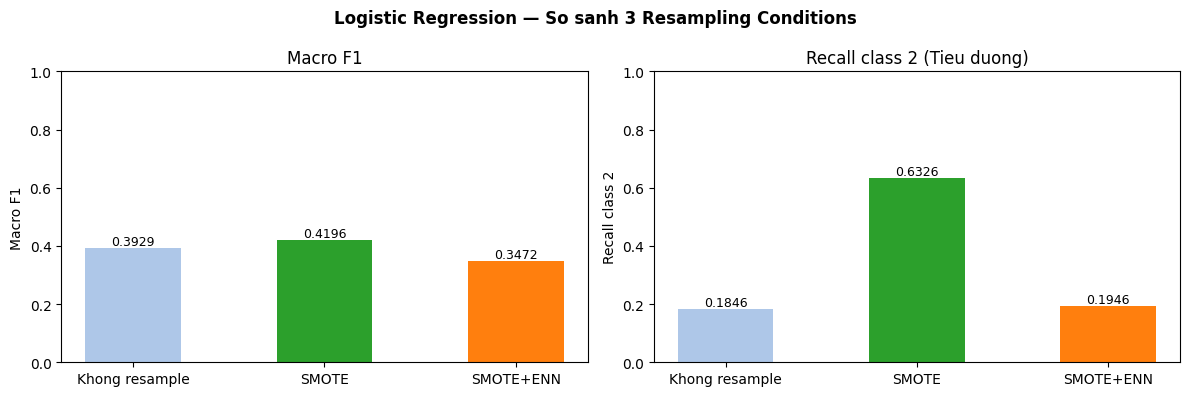

,Mo hinh,Dataset,Macro F1,Recall C2,ROC AUC,Time (s)
0,Logistic Regression,Khong resample,0.3929,0.1846,0.7655,3.5
1,Logistic Regression,SMOTE,0.4196,0.6326,0.7552,7.5
2,Logistic Regression,SMOTE+ENN,0.3472,0.1946,0.7530,3.8


In [22]:
all_results = []   # reset tránh nhân đôi khi chạy lại

lr = LogisticRegression(max_iter=1000, random_state=42)
run_model(lr, 'Logistic Regression')

## 2. RBF SVM (Radial Basis Function SVM)

SVM với kernel RBF ánh xạ dữ liệu lên không gian chiều cao hơn để tìm siêu phẳng phân tách phi tuyến. Phù hợp với dữ liệu phi tuyến, nhưng độ phức tạp **O(n²)** khiến việc train trên toàn bộ tập SMOTE (~500K mẫu) không khả thi. Mỗi điều kiện dùng **15,000 mẫu** chọn ngẫu nhiên (`random_state=42`) — đủ để so sánh tương đối giữa 3 điều kiện.


  RBF SVM
  [Khong resample (subset 15K) ]  Macro F1=0.3475  Recall C2=0.0751  ROC AUC=0.6275  (118.3s)
  [SMOTE (subset 15K)          ]  Macro F1=0.4093  Recall C2=0.6434  ROC AUC=0.7406  (264.1s)
  [SMOTE+ENN (subset 15K)      ]  Macro F1=0.3529  Recall C2=0.1912  ROC AUC=0.7406  (171.0s)


,Mo hinh,Dataset,Macro F1,Recall C2,ROC AUC,Time (s)
0,RBF SVM,Khong resample,0.3475,0.0751,0.6275,118.3
1,RBF SVM,SMOTE,0.4093,0.6434,0.7406,264.1
2,RBF SVM,SMOTE+ENN,0.3529,0.1912,0.7406,171.0


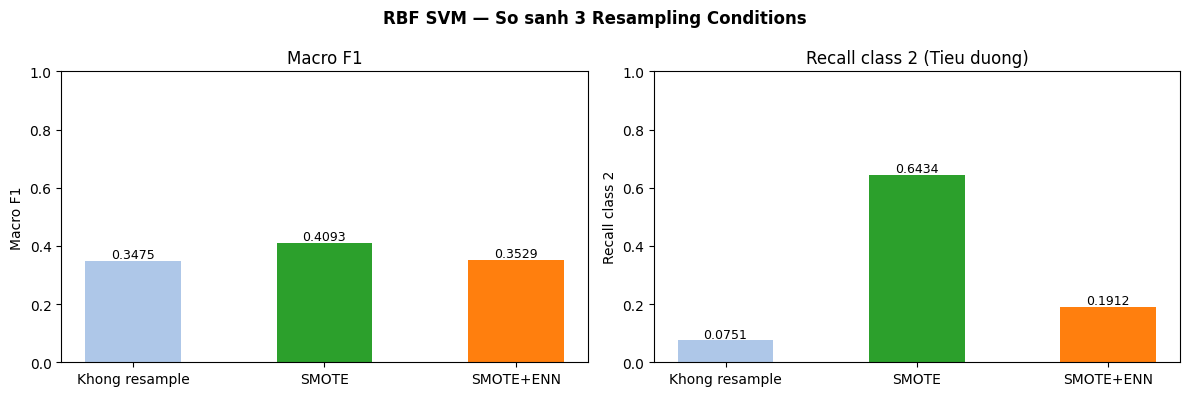

,Mo hinh,Dataset,Macro F1,Recall C2,ROC AUC,Time (s)
0,RBF SVM,Khong resample,0.3475,0.0751,0.6275,118.3
1,RBF SVM,SMOTE,0.4093,0.6434,0.7406,264.1
2,RBF SVM,SMOTE+ENN,0.3529,0.1912,0.7406,171.0


In [23]:
svm = SVC(kernel='rbf', probability=True, random_state=42)
run_model(svm, 'RBF SVM', subset_size=15_000)

## 3. Random Forest

Random Forest xây dựng nhiều Decision Tree độc lập trên các bootstrap samples và random subsets of features (bagging), kết hợp kết quả bằng majority vote. Phi tuyến, kháng overfitting tốt, hỗ trợ tính toán song song (`n_jobs=-1`). Đây chính là proxy model đã dùng trong Giai đoạn 1.


  Random Forest
  [Khong resample              ]  Macro F1=0.3989  Recall C2=0.2204  ROC AUC=0.6774  (11.0s)
  [SMOTE                       ]  Macro F1=0.4173  Recall C2=0.4545  ROC AUC=0.6665  (81.0s)
  [SMOTE+ENN                   ]  Macro F1=0.4166  Recall C2=0.4189  ROC AUC=0.6732  (37.9s)


,Mo hinh,Dataset,Macro F1,Recall C2,ROC AUC,Time (s)
0,Random Forest,Khong resample,0.3989,0.2204,0.6774,11.0
1,Random Forest,SMOTE,0.4173,0.4545,0.6665,81.0
2,Random Forest,SMOTE+ENN,0.4166,0.4189,0.6732,37.9


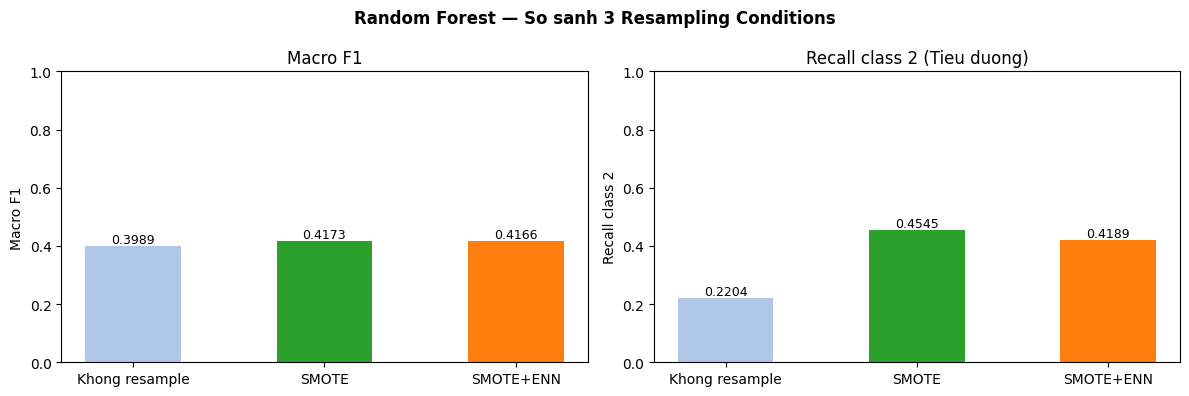

,Mo hinh,Dataset,Macro F1,Recall C2,ROC AUC,Time (s)
0,Random Forest,Khong resample,0.3989,0.2204,0.6774,11.0
1,Random Forest,SMOTE,0.4173,0.4545,0.6665,81.0
2,Random Forest,SMOTE+ENN,0.4166,0.4189,0.6732,37.9


In [24]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
run_model(rf, 'Random Forest')

## 4. XGBoost

XGBoost xây dựng các cây quyết định tuần tự, mỗi cây giảm residual error của các cây trước thông qua gradient descent — một trong những thuật toán mạnh nhất cho dữ liệu dạng bảng. Nhãn float (0.0/1.0/2.0) đã được chuyển sang int trong `datasets_exp`, XGBoost xử lý multiclass tự động với `eval_metric='mlogloss'`.


  XGBoost
  [Khong resample              ]  Macro F1=0.3880  Recall C2=0.1636  ROC AUC=0.7659  (3.2s)
  [SMOTE                       ]  Macro F1=0.4360  Recall C2=0.7089  ROC AUC=0.7473  (10.6s)
  [SMOTE+ENN                   ]  Macro F1=0.4442  Recall C2=0.4072  ROC AUC=0.7437  (4.7s)


,Mo hinh,Dataset,Macro F1,Recall C2,ROC AUC,Time (s)
0,XGBoost,Khong resample,0.3880,0.1636,0.7659,3.2
1,XGBoost,SMOTE,0.4360,0.7089,0.7473,10.6
2,XGBoost,SMOTE+ENN,0.4442,0.4072,0.7437,4.7


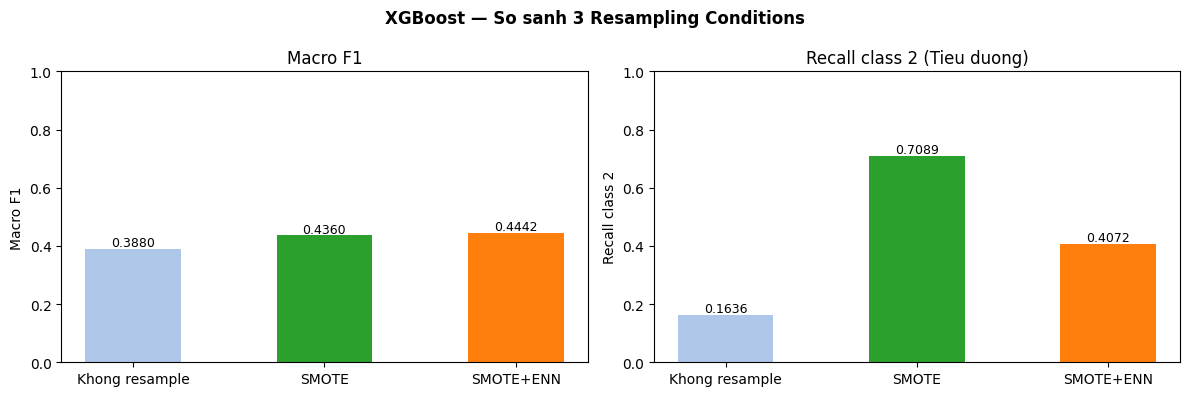

,Mo hinh,Dataset,Macro F1,Recall C2,ROC AUC,Time (s)
0,XGBoost,Khong resample,0.3880,0.1636,0.7659,3.2
1,XGBoost,SMOTE,0.4360,0.7089,0.7473,10.6
2,XGBoost,SMOTE+ENN,0.4442,0.4072,0.7437,4.7


In [25]:
xgb = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=6,
    random_state=42, n_jobs=-1, verbosity=0, eval_metric='mlogloss'
)
run_model(xgb, 'XGBoost')

## 5. MLP (Multi-Layer Perceptron)

MLP học các quan hệ phi tuyến phức tạp thông qua backpropagation với nhiều lớp ẩn. Kiến trúc `(128, 64)` — hai lớp ẩn 128 và 64 neurons — phù hợp với 10 features đầu vào. `early_stopping=True` dừng sớm khi validation loss không cải thiện, tránh overfitting và giảm thời gian train.


  MLP
  [Khong resample              ]  Macro F1=0.3850  Recall C2=0.1556  ROC AUC=0.7668  (83.7s)
  [SMOTE                       ]  Macro F1=0.3969  Recall C2=0.5891  ROC AUC=0.7013  (3059.0s)
  [SMOTE+ENN                   ]  Macro F1=0.3861  Recall C2=0.3369  ROC AUC=0.6916  (1984.1s)


,Mo hinh,Dataset,Macro F1,Recall C2,ROC AUC,Time (s)
0,MLP,Khong resample,0.3850,0.1556,0.7668,83.7
1,MLP,SMOTE,0.3969,0.5891,0.7013,3059.0
2,MLP,SMOTE+ENN,0.3861,0.3369,0.6916,1984.1


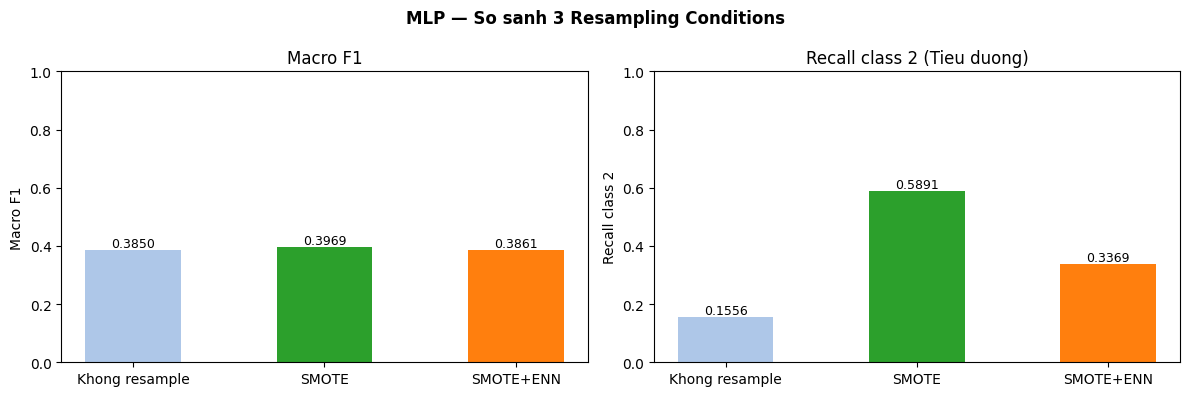

,Mo hinh,Dataset,Macro F1,Recall C2,ROC AUC,Time (s)
0,MLP,Khong resample,0.3850,0.1556,0.7668,83.7
1,MLP,SMOTE,0.3969,0.5891,0.7013,3059.0
2,MLP,SMOTE+ENN,0.3861,0.3369,0.6916,1984.1


In [26]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64), max_iter=200,
    early_stopping=True, random_state=42
)
run_model(mlp, 'MLP')

## Tổng hợp Kết quả — 5 Mô hình × 3 Điều kiện

Tổng hợp 15 thí nghiệm (5 mô hình × 3 điều kiện resampling) để xác định:
- **Mô hình nào** cho Macro F1 tổng thể tốt nhất?
- **Resampling method nào** cải thiện Recall class 2 nhiều nhất?
- **Tổ hợp nào** là tối ưu cho bài toán phân loại tiểu đường?

=== MACRO F1 ===


Dataset,Khong resample,SMOTE,SMOTE+ENN
Mo hinh,,,
Logistic Regression,0.3929,0.4196,0.3472
MLP,0.3850,0.3969,0.3861
RBF SVM,0.3475,0.4093,0.3529
Random Forest,0.3989,0.4173,0.4166
XGBoost,0.3880,0.4360,0.4442



=== RECALL CLASS 2 (Tieu duong) ===


Dataset,Khong resample,SMOTE,SMOTE+ENN
Mo hinh,,,
Logistic Regression,0.1846,0.6326,0.1946
MLP,0.1556,0.5891,0.3369
RBF SVM,0.0751,0.6434,0.1912
Random Forest,0.2204,0.4545,0.4189
XGBoost,0.1636,0.7089,0.4072



=== ROC AUC ===


Dataset,Khong resample,SMOTE,SMOTE+ENN
Mo hinh,,,
Logistic Regression,0.7655,0.7552,0.7530
MLP,0.7668,0.7013,0.6916
RBF SVM,0.6275,0.7406,0.7406
Random Forest,0.6774,0.6665,0.6732
XGBoost,0.7659,0.7473,0.7437


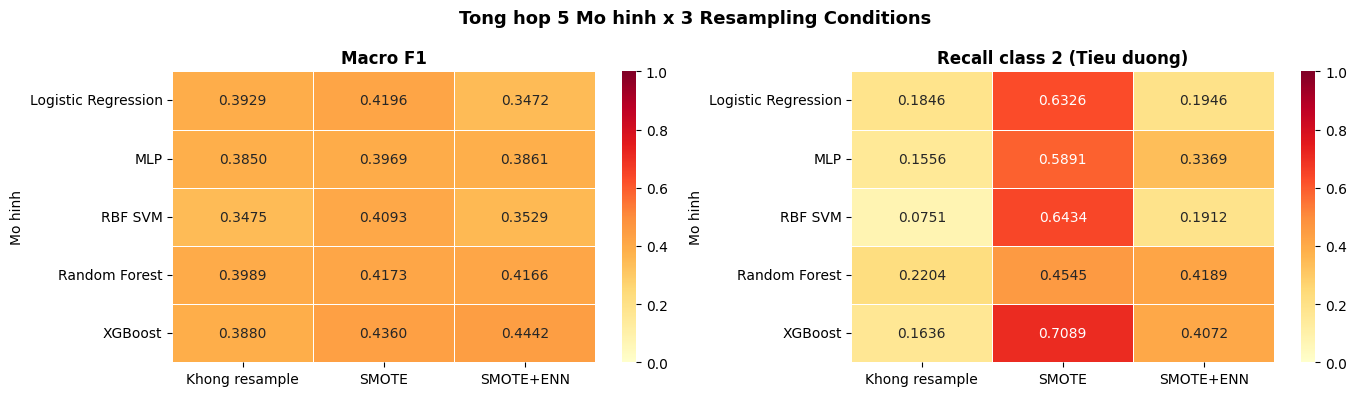


[Luu y] RBF SVM chi dung subset 15,000 mau/dieu kien (khong phai toan bo tap train).
        So sanh SVM voi cac mo hinh khac chi mang tinh tuong doi.

Tot nhat Macro F1:   [XGBoost + SMOTE+ENN]  F1=0.4442
Tot nhat Recall C2:  [XGBoost + SMOTE]  R2=0.7089


In [27]:
# Tong hop ket qua
summary_df = pd.DataFrame(all_results)

# Pivot Macro F1, Recall C2, ROC AUC (mo hinh x dieu kien)
col_order = ['Khong resample', 'SMOTE', 'SMOTE+ENN']
pivot_f1  = (summary_df.pivot(index='Mo hinh', columns='Dataset', values='Macro F1')
               .reindex(columns=col_order))
pivot_r2  = (summary_df.pivot(index='Mo hinh', columns='Dataset', values='Recall C2')
               .reindex(columns=col_order))
pivot_auc = (summary_df.pivot(index='Mo hinh', columns='Dataset', values='ROC AUC')
               .reindex(columns=col_order))

print("=== MACRO F1 ===")
display(pivot_f1)
print("\n=== RECALL CLASS 2 (Tieu duong) ===")
display(pivot_r2)
print("\n=== ROC AUC ===")
display(pivot_auc)

# Heatmap song song
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='YlOrRd',
            vmin=0, vmax=1, linewidths=0.5, ax=axes[0])
axes[0].set_title('Macro F1', fontweight='bold')
axes[0].set_xlabel('')

sns.heatmap(pivot_r2, annot=True, fmt='.4f', cmap='YlOrRd',
            vmin=0, vmax=1, linewidths=0.5, ax=axes[1])
axes[1].set_title('Recall class 2 (Tieu duong)', fontweight='bold')
axes[1].set_xlabel('')

plt.suptitle('Tong hop 5 Mo hinh x 3 Resampling Conditions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Ghi chu: RBF SVM chi dung subset 15,000 mau/dieu kien (do O(n^2) complexity)
# → khong so sanh truc tiep duoc voi cac mo hinh train tren tap day du
print("\n[Luu y] RBF SVM chi dung subset 15,000 mau/dieu kien (khong phai toan bo tap train).")
print("        So sanh SVM voi cac mo hinh khac chi mang tinh tuong doi.")

# Ket luan
best_f1 = summary_df.loc[summary_df['Macro F1'].idxmax()]
best_r2 = summary_df.loc[summary_df['Recall C2'].idxmax()]
print(f"\nTot nhat Macro F1:   [{best_f1['Mo hinh']} + {best_f1['Dataset']}]"
      f"  F1={best_f1['Macro F1']:.4f}")
print(f"Tot nhat Recall C2:  [{best_r2['Mo hinh']} + {best_r2['Dataset']}]"
      f"  R2={best_r2['Recall C2']:.4f}")

To hop tot nhat (Macro F1=0.4442): XGBoost + SMOTE+ENN


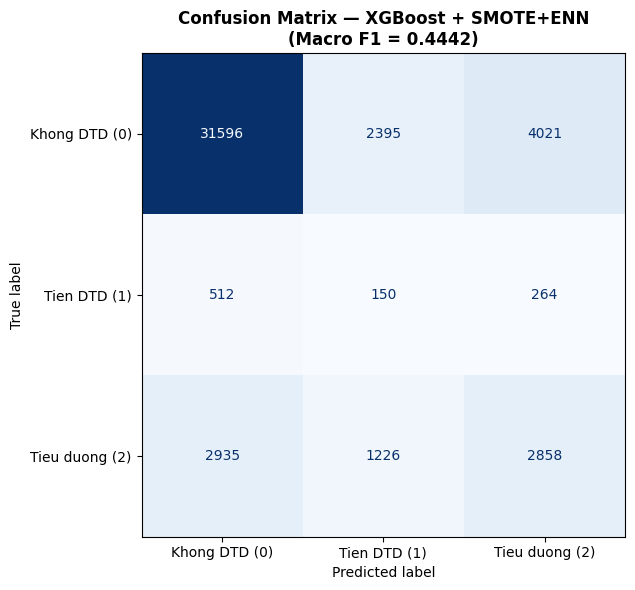

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Vẽ Confusion Matrix cho tổ hợp có Macro F1 cao nhất
best_row        = summary_df.loc[summary_df['Macro F1'].idxmax()]
best_model_name = best_row['Mo hinh']
best_dataset    = best_row['Dataset']
print(f"To hop tot nhat (Macro F1={best_row['Macro F1']:.4f}): {best_model_name} + {best_dataset}")

dataset_map = {
    'Khong resample': (np.array(X_train_top10), np.array(y_train_clean).astype(int)),
    'SMOTE':          (np.array(X_smote),        np.array(y_smote).astype(int)),
    'SMOTE+ENN':      (np.array(X_smote_enn),    np.array(y_smote_enn).astype(int)),
}
model_map = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'RBF SVM':             SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                                         random_state=42, n_jobs=-1, verbosity=0, eval_metric='mlogloss'),
    'MLP':                 MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=200,
                                         early_stopping=True, random_state=42),
}

X_tr_cm, y_tr_cm = dataset_map[best_dataset]
best_clf = model_map[best_model_name]

# SVM dung subset 15K de nhat quan voi run_model
if best_model_name == 'RBF SVM' and len(X_tr_cm) > 15_000:
    rng = np.random.RandomState(42)
    idx = rng.choice(len(X_tr_cm), 15_000, replace=False)
    X_tr_cm, y_tr_cm = X_tr_cm[idx], y_tr_cm[idx]

best_clf.fit(X_tr_cm, y_tr_cm)
y_pred_best = best_clf.predict(X_test_arr)

cm   = confusion_matrix(y_test_arr, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Khong DTD (0)', 'Tien DTD (1)', 'Tieu duong (2)'])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name} + {best_dataset}\n'
             f'(Macro F1 = {best_row["Macro F1"]:.4f})',
             fontweight='bold')
plt.tight_layout()
plt.show()